In [30]:
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
##courbe de bernstein 


In [44]:
## size of the figure

def plotCurve(Points,label,PointDeControle):
    fig = plt.figure()
    fig.set_size_inches(10, 10) 
    ax = fig.add_subplot(111, projection='3d')
    x = [point[0] for point in Points]
    y = [point[1] for point in Points]
    z = [point[2] for point in Points]
    ax.plot(x, y, z, label=label)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_zlim(0, 4)
    ax.legend()
    ax.scatter(PointDeControle[0][0], PointDeControle[0][1], PointDeControle[0][2], color='red', label='Point de contrôle A')
    ax.scatter(PointDeControle[1][0], PointDeControle[1][1], PointDeControle[1][2], color='green', label='Point de contrôle B')
    ax.scatter(PointDeControle[2][0], PointDeControle[2][1], PointDeControle[2][2], color='blue', label='Point de contrôle C')
    ax.scatter(PointDeControle[3][0], PointDeControle[3][1], PointDeControle[3][2], color='yellow', label='Point de contrôle D')    
    plt.show()

def bezier(t,PointDeControle):
    x = 0
    y = 0
    z = 0
    n = len(PointDeControle) - 1
    for i in range(len(PointDeControle)):
        b = math.factorial(n)/(math.factorial(i)*math.factorial(n-i))*(t**i)*((1-t)**(n-i))
        x += b*PointDeControle[i][0]
        y += b*PointDeControle[i][1]
        z += b*PointDeControle[i][2]
    return [x,y,z]

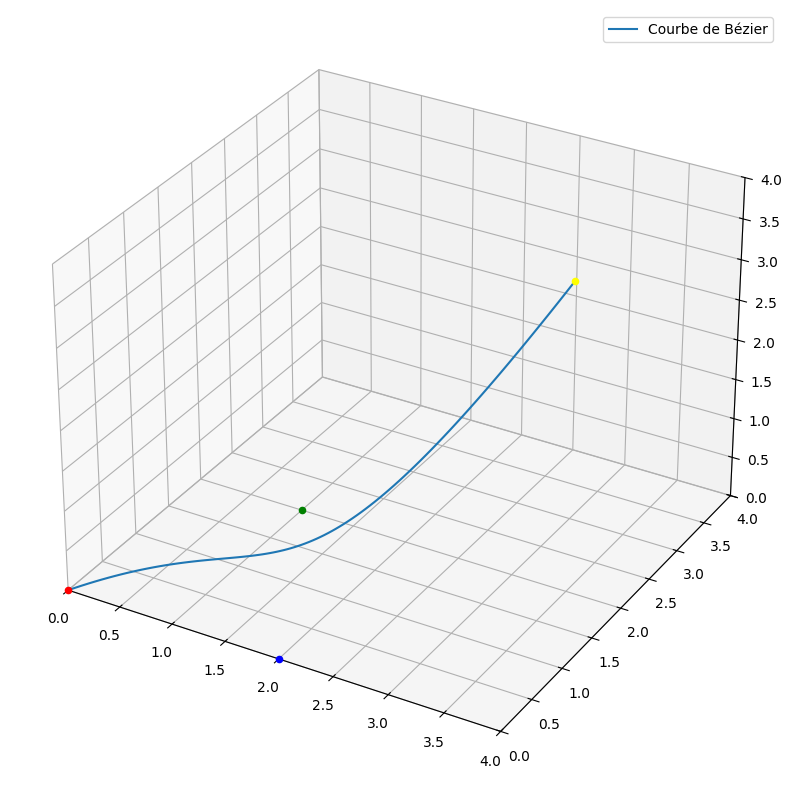

In [49]:
A = [0,0,0]
B = [1,2,0]
C = [2,0,0]
D = [3,3,3]

PointDeControle = [A,B,C,D]

t_values = [i/100 for i in range(101)]



bezier_points = [bezier(t,PointDeControle) for t in t_values]
plotCurve(bezier_points,"Courbe de Bézier",PointDeControle=PointDeControle)

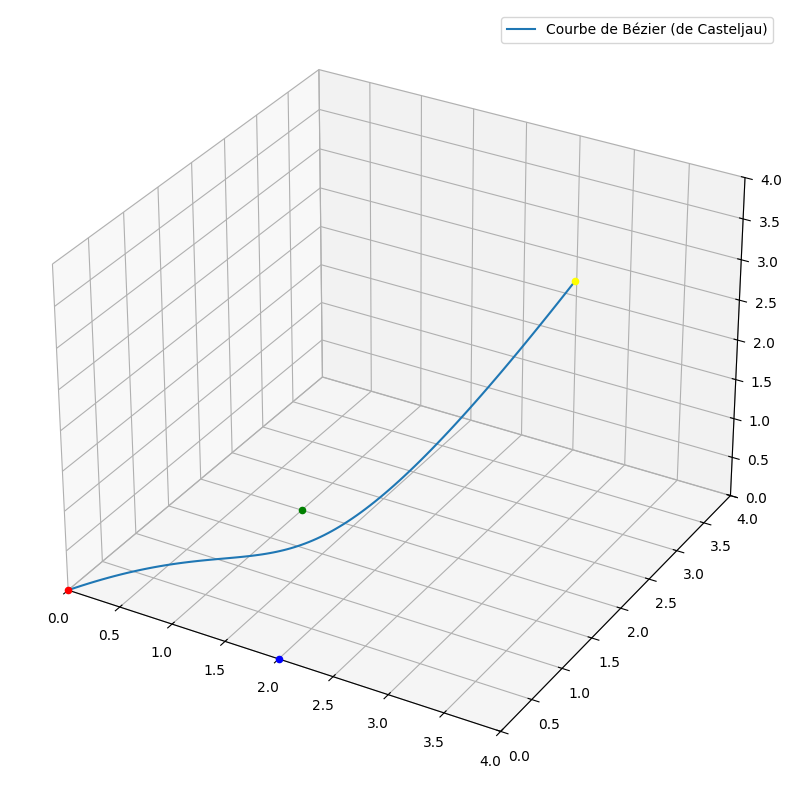

In [51]:
#// Calcul des points intermédiaires
#Pour j de 1 à N faire
# |
# | Pour i de 0 à N-j faire
# | |
# | | T[i][j] = t*T[i+1][j-1] + (1-t)*T[i][j-1]
# | |
# |
# Afficher T[0][N] // Afficher (ou stocker) le point
def deCasteljau(t, PointDeControle):
    n = len(PointDeControle)
    T = [[None for j in range(n)] for i in range(n)]
    for i in range(n):
        T[i][0] = PointDeControle[i]

    for j in range(1, n):
        for i in range(n - j):
            T[i][j] = [t * T[i + 1][j - 1][k] + (1 - t) * T[i][j - 1][k] for k in range(3)]

    
    return T[0][n - 1]



deCasteljau_points = [deCasteljau(t, PointDeControle) for t in t_values]
plotCurve(deCasteljau_points,"Courbe de Bézier (de Casteljau)",PointDeControle=PointDeControle)

Vecteur tangent à t=0.5: [3.0, 0.75, 2.25]


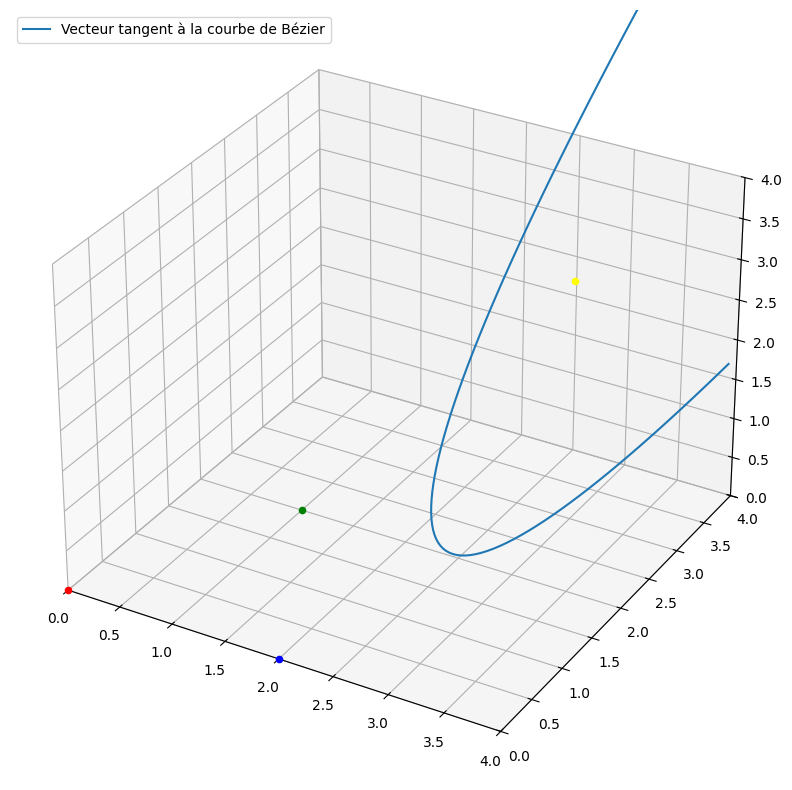

In [54]:
#. Calculer la dérivée (tangente) en un point donné.
def bezier_derivative(t, PointDeControle):
    n = len(PointDeControle) - 1
    derivative = [0, 0, 0]
    for i in range(n):
        b = math.factorial(n) / (math.factorial(i) * math.factorial(n - 1 - i)) * (t ** i) * ((1 - t) ** (n - 1 - i))
        derivative[0] += b * (PointDeControle[i + 1][0] - PointDeControle[i][0])
        derivative[1] += b * (PointDeControle[i + 1][1] - PointDeControle[i][1])
        derivative[2] += b * (PointDeControle[i + 1][2] - PointDeControle[i][2])
    return derivative
tangent_vector = bezier_derivative(0.5, PointDeControle)
print("Vecteur tangent à t=0.5:", tangent_vector)


tangente =[bezier_derivative(t,PointDeControle) for t in t_values]
plotCurve(tangente,"Vecteur tangent à la courbe de Bézier",PointDeControle=PointDeControle)




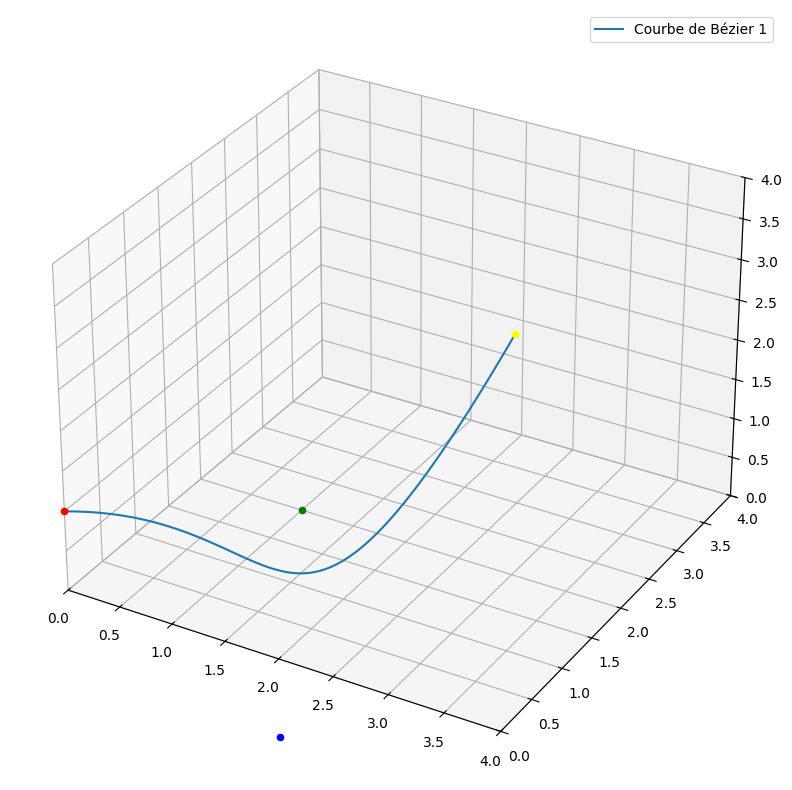

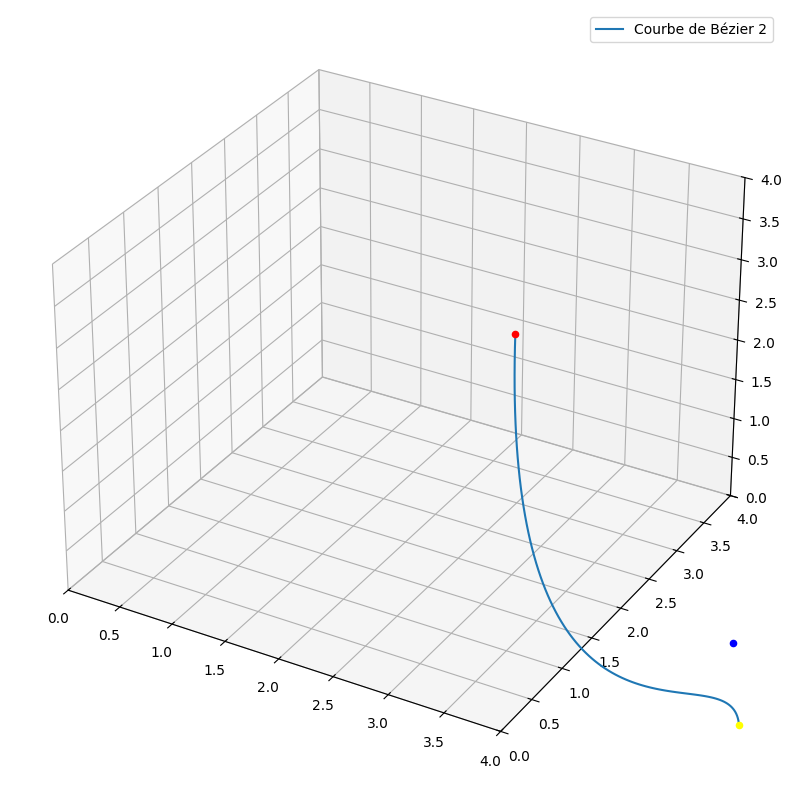

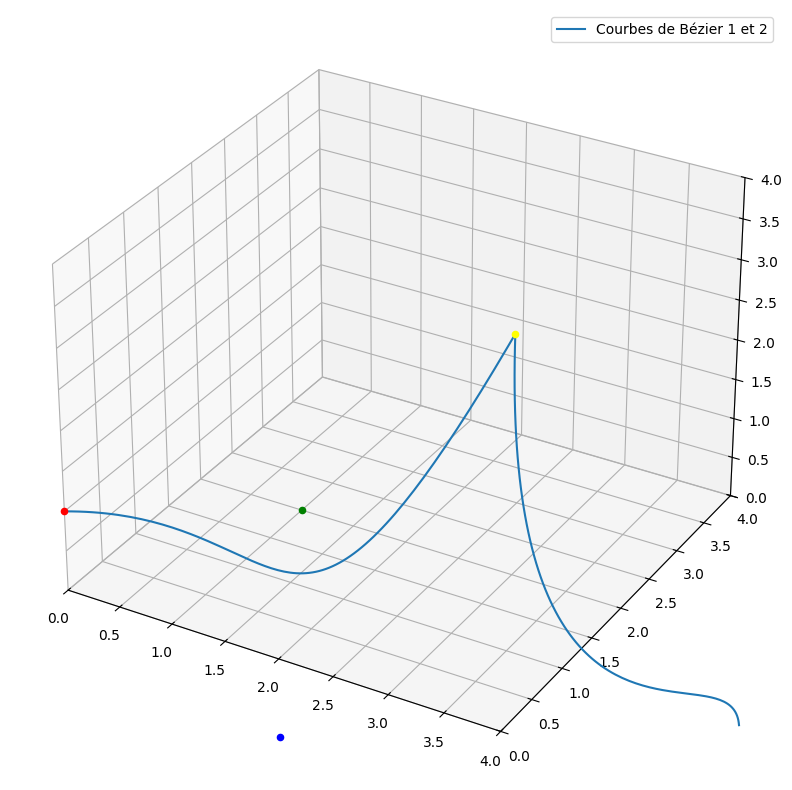

Point Q1 pour la continuité C1: [4, 4, 7]


In [55]:
#Continuité C1 de position et tangente Q1 = Q0 + (Pn-Pn-1)
def bezier_continuity(PointDeControle1, PointDeControle2):
    Pn_1 = PointDeControle1[-2]
    Pn = PointDeControle1[-1]
    Q0 = PointDeControle2[0]
    Q1 = [Q0[i] + (Pn[i] - Pn_1[i]) for i in range(3)]
    return Q1
PointDeControle1 = [[0, 0, 1], [1, 2, 0], [2, 0, -1], [3, 2, 3]]
PointDeControle2 = [[3, 2, 3], [4, 0, -1], [5, 2, 0], [6, 0, 1]]
Q1 = bezier_continuity(PointDeControle1, PointDeControle2)
bezier_points1 = [bezier(t, PointDeControle1) for t in t_values]
bezier_points2 = [bezier(t, PointDeControle2) for t in t_values]  
together = bezier_points1 + bezier_points2
plotCurve(bezier_points1,"Courbe de Bézier 1",PointDeControle=PointDeControle1)
plotCurve(bezier_points2,"Courbe de Bézier 2",PointDeControle=PointDeControle2)   
plotCurve(together,"Courbes de Bézier 1 et 2",PointDeControle=PointDeControle1+PointDeControle2 ) 
print("Point Q1 pour la continuité C1:", Q1)

